In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sentence_transformers\util.py:22: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.sparse import coo_matrix


In [12]:
df = pd.read_excel('../New folder/las3.18.xlsx')
nan_columns = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", nan_columns)

rows_of_users = []
for i,j in df.iterrows():
    sentence  = f"User is an {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent_Industry']} industry, working in a company with a turnover of {j['Turnover_Range']} and {j['Employees_Range']} employees. Their key areas of interest include {j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}, {j['aoi_4']}, and {j['aoi_5']}."
    rows_of_users.append(sentence)

Columns with NaNs: []


In [ ]:
df1 = pd.read_excel('./updated.xlsx')
nan_columns = df1.columns[df1.isna().any()].tolist()
print("Columns with NaNs:", nan_columns)

rows_of_users_1= []
for i,j in df1.iterrows():
    sentence  = f"User is an {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent_Industry']} industry, working in a company with a turnover of {j['Turnover_Range']} and {j['Employees_Range']} employees. Their key areas of interest include {j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}, {j['aoi_4']}, and {j['aoi_5']}."
    rows_of_users_1.append(sentence)

In [ ]:
base = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [ ]:
embedding = base.encode(rows_of_users, normalize_embeddings=True)

In [ ]:
embedding_1 = base.encode(rows_of_users_1, normalize_embeddings=True)

In [7]:
# embeddings_array = np.array(embedding)
# embeddings_array_1 = np.array(embedding_1)
# np.save('embeddings.npy', embeddings_array)
# np.save('embeddings_1.npy', embeddings_array_1)

loaded_embeddings = np.load('../New folder/embeddings.npy')
loaded_embeddings_1 = np.load('../New folder/embeddings_1.npy')

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(loaded_embeddings)
embeddings_scaled_1 = scaler.fit_transform(loaded_embeddings_1)


In [8]:
def find_elbow_simple(X, max_k=10):
    inertias = []
    k_range = range(1, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.grid(True)
    plt.show()

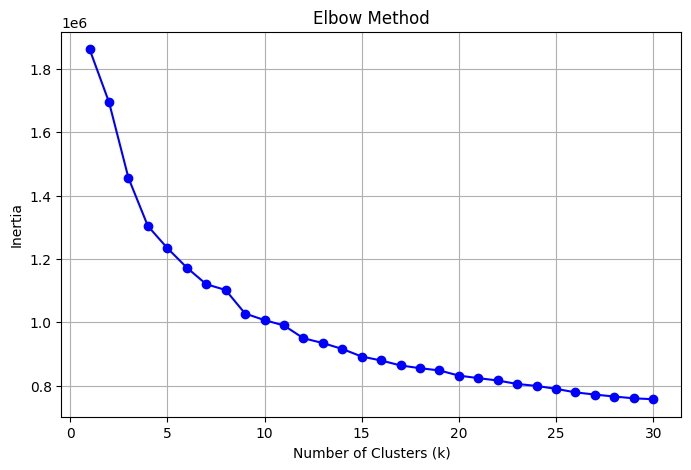

In [9]:
find_elbow_simple(embeddings_scaled, max_k=30)

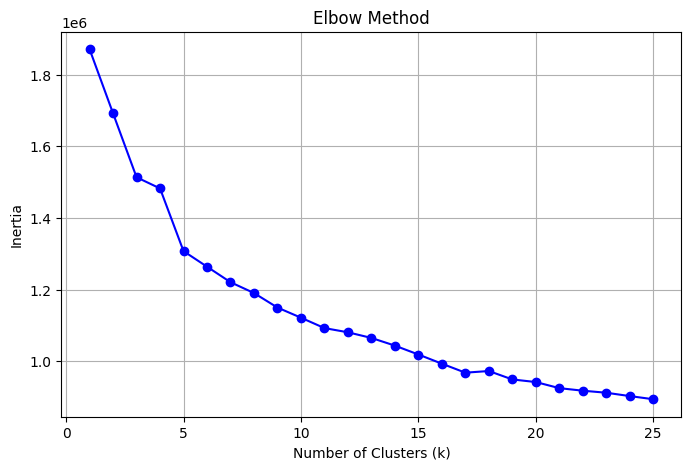

In [ ]:
find_elbow_simple(embeddings_scaled_1, max_k=25)

In [13]:

kmeans = KMeans(n_clusters=12, random_state=42)
inertias=kmeans.fit_predict(embeddings_scaled)
df["clusters"]=inertias
#df.to_excel("kmeans.xlsx")


In [ ]:
kmeans = KMeans(n_clusters=17, random_state=42)
inertias=kmeans.fit_predict(embeddings_scaled_1)
df1["clusters"]=inertias
df1.to_excel("kmeans1.xlsx")

NameError: name 'KMeans' is not defined

In [15]:
top_industries = (
    df.groupby(['clusters','Parent_Industry','Job_Seniority','Job_Function'])
      .size()
      .reset_index(name='count')
      .sort_values(['clusters', 'count'], ascending=[True, False])
      .groupby('clusters')
      .head(2)
)

In [16]:
top_industries.to_excel("./test_km.xlsx")